In [255]:
import os
import numpy as np
import glob
from PIL import Image, ImageDraw, ImageStat

# pip install torchsummary
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision import models
from torchsummary import summary
import torch.optim as optim
from time import time

import matplotlib.pyplot as plt
from IPython.display import clear_output
import random
from scipy.ndimage import measurements
from skimage import measure
from scipy.ndimage import distance_transform_edt
from glob import glob
import os
import pandas as pd
from torchvision import transforms as T

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
import sys
sys.path.append('/zhome/a4/f/202251/projects/02516-IDLCV/')

cuda


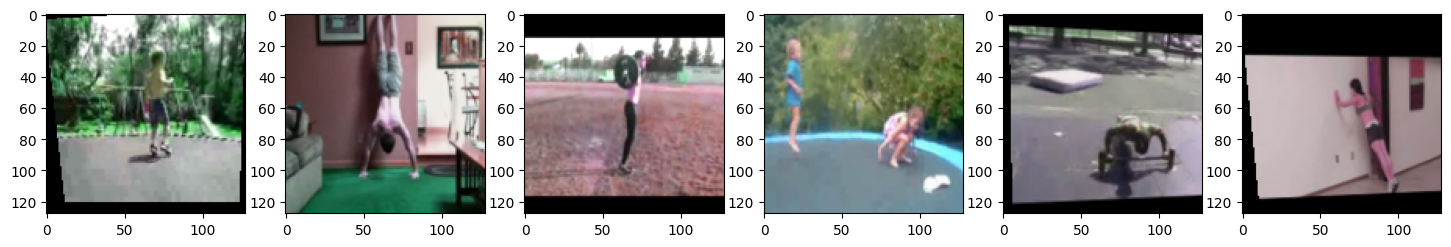

In [428]:

import torch.nn.functional as F

class FrameImageDataset(torch.utils.data.Dataset):
    def __init__(self,
    root_dir='/work3/ppar/data/ucf101_noleakage',
    split='train',
    transform=None
):
        self.frame_paths = sorted(glob(f'{root_dir}/frames/{split}/*/*/*.jpg'))
        self.df = pd.read_csv(f'{root_dir}/metadata/{split}.csv')
        self.split = split
        self.transform = transform
        # breakpoint()

    def __len__(self):
        return len(self.frame_paths)

    def _get_meta(self, attr, value):
        return self.df.loc[self.df[attr] == value]

    def __getitem__(self, idx):
        frame_path = self.frame_paths[idx]

        video_name = frame_path.split('/')[-2]
        video_meta = self._get_meta('video_name', video_name)
        label = video_meta['label'].item()

        frame = Image.open(frame_path).convert("RGB")

        if self.transform:
            frame = self.transform(frame)
        else:
            frame = T.ToTensor()(frame)

        return frame, label


class FrameVideoDataset(torch.utils.data.Dataset):
    def __init__(self,
    root_dir = '/work3/ppar/data/ucf101_noleakage',
    split = 'train',
    transform = None,
    stack_frames = True
):

        self.video_paths = sorted(glob(f'{root_dir}/videos/{split}/*/*.avi'))
        self.df = pd.read_csv(f'{root_dir}/metadata/{split}.csv')
        self.split = split
        self.transform = transform
        self.stack_frames = stack_frames

        self.n_sampled_frames = 10

    def __len__(self):
        return len(self.video_paths)

    def _get_meta(self, attr, value):
        return self.df.loc[self.df[attr] == value]

    def __getitem__(self, idx):
        video_path = self.video_paths[idx]
        video_name = video_path.split('/')[-1].split('.avi')[0]
        video_meta = self._get_meta('video_name', video_name)
        label = video_meta['label'].item()

        video_frames_dir = self.video_paths[idx].split('.avi')[0].replace('videos', 'frames')
        video_frames = self.load_frames(video_frames_dir)

        if self.transform:
            frames = [self.transform(frame) for frame in video_frames]
        else:
            frames = [T.ToTensor()(frame) for frame in video_frames]

        if self.stack_frames:
            frames = torch.stack(frames).permute(1, 0, 2, 3)


        return frames, label

    def load_frames(self, frames_dir):
        frames = []
        for i in range(1, self.n_sampled_frames + 1):
            frame_file = os.path.join(frames_dir, f"frame_{i}.jpg")
            frame = Image.open(frame_file).convert("RGB")
            frames.append(frame)

        return frames


class FlowVideoDataset(torch.utils.data.Dataset):
    def __init__(self,
    root_dir = '/work3/ppar/data/ucf101_noleakage',
    split = 'train',
    resize = (64,64),
    transform = None,
):

        self.video_paths = sorted(glob(f'{root_dir}/videos/{split}/*/*.avi'))
        self.df = pd.read_csv(f'{root_dir}/metadata/{split}.csv')
        self.split = split
        self.resize = resize
        self.n_sampled_frames = 10
        self.transform = transform

    def __len__(self):
        return len(self.video_paths)

    def _get_meta(self, attr, value):
        return self.df.loc[self.df[attr] == value]

    def __getitem__(self, idx):
        video_path = self.video_paths[idx]
        video_name = video_path.split('/')[-1].split('.avi')[0]
        video_meta = self._get_meta('video_name', video_name)
        label = video_meta['label'].item()

        video_flows_dir = self.video_paths[idx].split('.avi')[0].replace('videos', 'flows')
        flows = self.load_flows(video_flows_dir)

        video_frames_dir = self.video_paths[idx].split('.avi')[0].replace('videos', 'frames')
        frame = self.load_frames(video_frames_dir)

        if self.transform:
            frames = self.transform(frame)
        else:
            frames = T.ToTensor()(frame)

        # frames = frames.permute(1, 0, 2, 3)

        return frames, flows, label

    def load_flows(self, flows_dir):
        flows = []
        for i in range(1, self.n_sampled_frames):
            flow_file = os.path.join(f'{flows_dir}', f"flow_{i}_{i+1}.npy")
            flow = np.load(flow_file)
            flow = torch.from_numpy(flow)
            flows.append(flow)
        flows = torch.stack(flows)

        if self.resize:
            flows = F.interpolate(flows, size=self.resize, mode='bilinear')

        return flows.flatten(0,1)

    def load_frames(self, frames_dir):
        frames = []
        for i in range(1, self.n_sampled_frames + 1):
            frame_file = os.path.join(frames_dir, f"frame_{i}.jpg")
            frame = Image.open(frame_file).convert("RGB")
            frames.append(frame)

        return random.choice(frames)

root_dir = '/zhome/a4/f/202251/projects/02516-IDLCV/data/ucf101_noleakage'

                # transforms.Resize((img_size + 8, img_size + 8)),
                # transforms.RandomPerspective(distortion_scale=0.6, p=1.0),
                # transforms.RandomRotation(degrees=(0, 20)),
                # transforms.RandomCrop((img_size, img_size)),
                # transforms.RandomPosterize(bits=2),
                # transforms.RandomHorizontalFlip(p=0.7),
                # transforms.ColorJitter(brightness=.3, hue=.3),
                # transforms.ToTensor(),
                # transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])

transform = T.Compose([T.Resize((135, 135)),
                transforms.RandomHorizontalFlip(),
                transforms.RandomPerspective(distortion_scale=0.2, p=0.4),
                transforms.RandomCrop((128, 128)),
                transforms.ColorJitter(brightness=.2, hue=.2),
                transforms.ToTensor(),
                # transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
                # transforms.Normalize(mean=[0.43355902, 0.42063938, 0.38674581],std=[0.27587394, 0.27081611, 0.27745165])
            ])

frameimage_train_dataset = FrameImageDataset(root_dir=root_dir, split='train', transform=transform)
framevideostack_train_dataset = FrameVideoDataset(root_dir=root_dir, split='train', transform=transform, stack_frames = True)
framevideolist_train_dataset = FrameVideoDataset(root_dir=root_dir, split='train', transform=transform, stack_frames = False)
flowvideo_train_dataset = FlowVideoDataset(root_dir=root_dir, transform=transform, split='train', resize=(64,64))

frameimage_val_dataset = FrameImageDataset(root_dir=root_dir, split='val')
framevideostack_val_dataset = FrameVideoDataset(root_dir=root_dir, split='val', stack_frames = True)
framevideolist_val_dataset = FrameVideoDataset(root_dir=root_dir, split='val', stack_frames = False)
flowvideo_val_dataset = FlowVideoDataset(root_dir=root_dir, split='val', resize=(64,64))

frameimage_test_dataset = FrameImageDataset(root_dir=root_dir, split='test')
framevideostack_test_dataset = FrameVideoDataset(root_dir=root_dir, split='test', stack_frames = True)
framevideolist_test_dataset = FrameVideoDataset(root_dir=root_dir, split='test', stack_frames = False)
flowvideo_test_dataset = FlowVideoDataset(root_dir=root_dir, split='test', resize=(64,64))

# loader
frameimage_train_loader = DataLoader(frameimage_train_dataset,  batch_size=32, shuffle=True)
framevideostack_train_loader = DataLoader(framevideostack_train_dataset,  batch_size=16, shuffle=True)
framevideolist_train_loader = DataLoader(framevideolist_train_dataset,  batch_size=16, shuffle=True)
flowvideo_train_loader = DataLoader(flowvideo_train_dataset,  batch_size=32, shuffle=True)


frameimage_val_loader = DataLoader(frameimage_val_dataset,  batch_size=8, shuffle=False)
framevideostack_val_loader = DataLoader(framevideostack_val_dataset,  batch_size=8, shuffle=False)
framevideolist_val_loader = DataLoader(framevideolist_val_dataset,  batch_size=8, shuffle=False)
flowvideo_val_loader = DataLoader(flowvideo_val_dataset,  batch_size=8, shuffle=False)

frameimage_test_loader = DataLoader(frameimage_test_dataset,  batch_size=8, shuffle=False)
framevideostack_test_loader = DataLoader(framevideostack_test_dataset,  batch_size=8, shuffle=False)
framevideolist_test_loader = DataLoader(framevideolist_test_dataset,  batch_size=8, shuffle=False)
flowvideo_test_loader = DataLoader(flowvideo_test_dataset,  batch_size=8, shuffle=False)

plt.rcParams['figure.figsize'] = [18, 6]

images, labels = next(iter(frameimage_train_loader))

for i in range(6):
    plt.subplot(1, 6, i+1)
    plt.imshow(np.swapaxes(np.swapaxes(images[i], 0, 2), 0, 1))
plt.show()

from operator import add
class Stats(ImageStat.Stat):
    def __add__(self, other):
        return Stats(list(map(add, self.h, other.h)))

# loader = DataLoader(FrameImageDataset(root_dir=root_dir, split='train'), batch_size=10, num_workers=5)

# statistics = None
# for data in loader:
#     data = data[0]
#     for b in range(data.shape[0]):
#         if statistics is None:
#             statistics = Stats(transforms.functional.to_pil_image(data[b]))
#         else:
#             statistics += Stats(transforms.functional.to_pil_image(data[b]))
# print(f'mean:{np.array(statistics.mean) / 255}, std:{np.array(statistics.stddev) / 255}')


In [380]:
import torchvision.models as models
from torchvision.models import ResNet101_Weights, ResNet18_Weights, VGG16_Weights, ResNet18_Weights, ResNet34_Weights, ResNet50_Weights

class SpatialNet(nn.Module):
  def __init__(self, num_classes):
    super().__init__()

    self.num_classes = num_classes
    self.net = models.resnet50(weights=ResNet50_Weights.DEFAULT).to(device)
    # self.net.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
    self.net.fc = nn.Sequential(
            nn.Dropout(p=0.6),
            nn.Linear(in_features=2048, out_features=num_classes)
        )
    # self.dropout = nn.Dropout(0.5)
    # self.fc2 = nn.Linear(in_features=2048, out_features=10)

  def forward(self, x):
    # x = x.reshape(x.shape[0], x.shape[1] * x.shape[2], x.shape[3], x.shape[4])
    x = self.net(x)
    # x = self.dropout(x)
    # x = self.fc2(x)

    return x

class TemporatNet(nn.Module):
  def __init__(self, num_classes):
    super().__init__()

    self.num_classes = num_classes

    self.net = models.resnet101(weights=ResNet101_Weights.DEFAULT).to(device)
    self.net.conv1 = nn.Conv2d(18, 64, kernel_size=7, stride=2, padding=3,bias=False)
    self.net.fc = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_features=2048, out_features=num_classes))

  def forward(self, x):
    x = self.net(x)

    return x

class TwoStreamNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.spatial_stream = SpatialNet(num_classes)
        self.temporal_stream = TemporatNet(num_classes)

    def forward(self, spatial_input, temporal_input):
        spatial_output = self.spatial_stream(spatial_input)
        temporal_output = self.temporal_stream(temporal_input)

        # spatial_softmax = F.softmax(spatial_output, dim=1)
        # temporal_softmax = F.softmax(temporal_output, dim=1)
        return (spatial_output + temporal_output), spatial_output, temporal_output


In [303]:
def evaluate_model(model, dataloader):
    model.eval()  # Set the model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for video_frames, labels in dataloader:
            video_frames, labels = video_frames.to(device), labels.to(device)
            outputs = model(video_frames)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    print(f"Validation Accuracy: {accuracy:.4f}")

def train(model, train_loader, val_loader, criterion, optimizer, num_epochs = 20):

  model.train()
  for epoch in range(num_epochs):
    epoch_loss = 0;

    for frames, labels in train_loader:
      frames, labels = frames.to(device), labels.to(device)
      optimizer.zero_grad()
      output = model(frames)
      loss = criterion(output, labels)
      loss.backward()
      optimizer.step()

      # Track loss and accuracy
      epoch_loss += loss.item()

    # val
    evaluate_model(model, val_loader)
    model.train()

    # epoch_acc = correct / total
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")



In [310]:
sm = SpatialNet(10).to(device)
# averageModel = TwoStreamNet(10).to(device)
criterion = nn.CrossEntropyLoss()

# for param in sm.net.parameters():
#     param.requires_grad = False
# # Unfreeze the final fully connected layer
# for param in sm.net.fc.parameters():
#     param.requires_grad = True

optimizer = torch.optim.AdamW(sm.parameters(), lr=0.0001, weight_decay=1e-4)
train(sm, frameimage_train_loader, frameimage_val_loader, criterion, optimizer)
# train(sm, framevideostack_train_loader, framevideostack_val_loader, criterion, optimizer)

print('sssss done')

Validation Accuracy: 0.4825
Epoch 1/20, Loss: 144.0135
Validation Accuracy: 0.5283
Epoch 2/20, Loss: 6.2748
Validation Accuracy: 0.5150
Epoch 3/20, Loss: 2.1564
Validation Accuracy: 0.5050
Epoch 4/20, Loss: 1.3175
Validation Accuracy: 0.4917
Epoch 5/20, Loss: 1.5199
Validation Accuracy: 0.5308
Epoch 6/20, Loss: 2.0623
Validation Accuracy: 0.5392
Epoch 7/20, Loss: 1.1351
Validation Accuracy: 0.5375
Epoch 8/20, Loss: 1.3872
Validation Accuracy: 0.5425
Epoch 9/20, Loss: 0.9009
Validation Accuracy: 0.5000
Epoch 10/20, Loss: 0.6163
Validation Accuracy: 0.5408
Epoch 11/20, Loss: 0.7513
Validation Accuracy: 0.4817
Epoch 12/20, Loss: 1.5274
Validation Accuracy: 0.5392
Epoch 13/20, Loss: 1.0444
Validation Accuracy: 0.5408
Epoch 14/20, Loss: 0.3877
Validation Accuracy: 0.5183
Epoch 15/20, Loss: 0.5239
Validation Accuracy: 0.5158
Epoch 16/20, Loss: 0.8247
Validation Accuracy: 0.5242
Epoch 17/20, Loss: 0.8188
Validation Accuracy: 0.5500
Epoch 18/20, Loss: 0.5797
Validation Accuracy: 0.5808
Epoch 1

In [350]:
sm3 = SpatialNet(10).to(device)
# print(sm2.net.parameters())

# # averageModel = TwoStreamNet(10).to(device)
criterion = nn.CrossEntropyLoss()
counter = 0
for param in sm3.net.parameters():
    if (counter >= 50):
      break;
    counter +=1
    param.requires_grad = False
# # Unfreeze the final fully connected layer
# for param in sm2.net.fc.parameters():
#     param.requires_grad = True

optimizer = torch.optim.AdamW(sm3.parameters(), lr=0.0001, weight_decay=1e-4)
train(sm3, frameimage_train_loader, frameimage_val_loader, criterion, optimizer, num_epochs=10)

Validation Accuracy: 0.5625
Epoch 1/10, Loss: 164.7066
Validation Accuracy: 0.5792
Epoch 2/10, Loss: 8.1523
Validation Accuracy: 0.6008
Epoch 3/10, Loss: 2.6918
Validation Accuracy: 0.6067
Epoch 4/10, Loss: 1.4770
Validation Accuracy: 0.6125
Epoch 5/10, Loss: 1.6505
Validation Accuracy: 0.5825
Epoch 6/10, Loss: 1.0125
Validation Accuracy: 0.5717
Epoch 7/10, Loss: 0.7440
Validation Accuracy: 0.5825
Epoch 8/10, Loss: 0.3658
Validation Accuracy: 0.5617
Epoch 9/10, Loss: 0.7749
Validation Accuracy: 0.5767
Epoch 10/10, Loss: 0.9671


In [352]:
torch.save(sm3.state_dict(), '/zhome/a4/f/202251/projects/02516-IDLCV/scripts/sm3.pth')

In [381]:
tm = TemporatNet(10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(tm.parameters(), lr=0.0001, weight_decay=1e-4)
train(tm, flowvideo_train_loader, flowvideo_val_loader, criterion, optimizer, num_epochs=30)
# torch.save(tm.state_dict(), '/zhome/a4/f/202251/projects/02516-IDLCV/scripts/tm.pth')

Validation Accuracy: 0.1583
Epoch 1/30, Loss: 74.4896
Validation Accuracy: 0.2000
Epoch 2/30, Loss: 68.9953
Validation Accuracy: 0.2750
Epoch 3/30, Loss: 65.1861
Validation Accuracy: 0.3250
Epoch 4/30, Loss: 59.2874
Validation Accuracy: 0.4417
Epoch 5/30, Loss: 53.4863
Validation Accuracy: 0.5417
Epoch 6/30, Loss: 45.8169
Validation Accuracy: 0.4750
Epoch 7/30, Loss: 37.0010
Validation Accuracy: 0.5417
Epoch 8/30, Loss: 30.0288
Validation Accuracy: 0.5333
Epoch 9/30, Loss: 24.6763
Validation Accuracy: 0.5833
Epoch 10/30, Loss: 20.9155
Validation Accuracy: 0.6250
Epoch 11/30, Loss: 15.7923
Validation Accuracy: 0.5833
Epoch 12/30, Loss: 13.7683
Validation Accuracy: 0.5500
Epoch 13/30, Loss: 13.2830
Validation Accuracy: 0.5667
Epoch 14/30, Loss: 10.8823
Validation Accuracy: 0.5750
Epoch 15/30, Loss: 9.1665
Validation Accuracy: 0.6083
Epoch 16/30, Loss: 8.3855
Validation Accuracy: 0.6583
Epoch 17/30, Loss: 8.1564
Validation Accuracy: 0.6167
Epoch 18/30, Loss: 6.8238
Validation Accuracy: 0.

In [382]:
tm2 = TemporatNet(10).to(device)
criterion = nn.CrossEntropyLoss()
counter = 0
for param in tm2.net.parameters():
    if (counter >= 50):
      break;
    counter +=1
    param.requires_grad = False
optimizer = torch.optim.AdamW(tm2.parameters(), lr=0.0001, weight_decay=1e-4)
train(tm2, flowvideo_train_loader, flowvideo_val_loader, criterion, optimizer, num_epochs=30)

Validation Accuracy: 0.1500
Epoch 1/30, Loss: 75.0141
Validation Accuracy: 0.2167
Epoch 2/30, Loss: 70.9570
Validation Accuracy: 0.2167
Epoch 3/30, Loss: 66.5038
Validation Accuracy: 0.3000
Epoch 4/30, Loss: 59.2959
Validation Accuracy: 0.4167
Epoch 5/30, Loss: 50.9311
Validation Accuracy: 0.4417
Epoch 6/30, Loss: 44.6348
Validation Accuracy: 0.4417
Epoch 7/30, Loss: 37.5866
Validation Accuracy: 0.5167
Epoch 8/30, Loss: 30.0118
Validation Accuracy: 0.4500
Epoch 9/30, Loss: 24.3287
Validation Accuracy: 0.4583
Epoch 10/30, Loss: 21.7251
Validation Accuracy: 0.4917
Epoch 11/30, Loss: 16.5374
Validation Accuracy: 0.5083
Epoch 12/30, Loss: 13.0553
Validation Accuracy: 0.4667
Epoch 13/30, Loss: 11.6893
Validation Accuracy: 0.5250
Epoch 14/30, Loss: 10.2961
Validation Accuracy: 0.5000
Epoch 15/30, Loss: 8.3013
Validation Accuracy: 0.4750
Epoch 16/30, Loss: 8.4858


KeyboardInterrupt: 

In [383]:
torch.save(tm.state_dict(), '/zhome/a4/f/202251/projects/02516-IDLCV/scripts/tm.pth')

In [429]:
class SpatialNet2(nn.Module):
  def __init__(self):
    super().__init__()

    self.net = models.resnet50(weights=ResNet50_Weights.DEFAULT).to(device)
    # self.net.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
    self.net.fc = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_features=2048, out_features=1024),
            nn.Dropout(p=0.5),
        )

  def forward(self, x):
    x = self.net(x)

    return x

class TemporatNet2(nn.Module):
  def __init__(self):
    super().__init__()

    self.net = models.resnet50(weights=ResNet50_Weights.DEFAULT).to(device)
    self.net.conv1 = nn.Conv2d(18, 64, kernel_size=7, stride=2, padding=3,bias=False)
    self.net.fc = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_features=2048, out_features=1024),
            nn.Dropout(p=0.5),
        )

  def forward(self, x):
    x = self.net(x)

    return x

class TwoStreamNet2(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.spatial_stream = SpatialNet2()
        self.temporal_stream = TemporatNet2()
        self.fn =  nn.Sequential(
            # nn.Dropout(p=0.5),
            nn.Linear(in_features=1024*2, out_features=1024),
            nn.Dropout(p=0.5),
            nn.Linear(in_features=1024, out_features=num_classes)
        )

    def forward(self, spatial_input, temporal_input):
        spatial_output = self.spatial_stream(spatial_input)
        temporal_output = self.temporal_stream(temporal_input)

        return self.fn(torch.cat((spatial_output, temporal_output), dim=1))


def evaluate_model2(model, dataloader):
    model.eval()  # Set the model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for images, flows, labels in dataloader:
          frames, flows, labels = images.to(device), flows.to(device), labels.to(device)

          outputs = model(frames, flows)
          _, predicted = torch.max(outputs.data, 1)
          total += labels.size(0)
          correct += (predicted == labels).sum().item()

    accuracy = correct / total
    print(f"Validation Accuracy: {accuracy:.4f}")

def train2(model, train_loader, val_loader, criterion, optimizer, num_epochs = 20):
  model.train()
  for epoch in range(num_epochs):
    epoch_loss = 0;

    for images, flows, labels in train_loader:
      frames, flows, labels = images.to(device), flows.to(device), labels.to(device)
      optimizer.zero_grad()
      output = model(frames, flows)
      loss = criterion(output, labels)
      loss.backward()
      optimizer.step()

      # Track loss and accuracy
      epoch_loss += loss.item()

    # val
    evaluate_model2(model, val_loader)
    model.train()

    # epoch_acc = correct / total
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")


tsn = TwoStreamNet2(10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(tsn.parameters(), lr=0.0001, weight_decay=1e-4, betas = [0.9, 0.999])
train2(tsn, flowvideo_train_loader, flowvideo_val_loader, criterion, optimizer, num_epochs=30)

Validation Accuracy: 0.1917
Epoch 1/30, Loss: 36.3497
Validation Accuracy: 0.4500
Epoch 2/30, Loss: 32.5138
Validation Accuracy: 0.4750
Epoch 3/30, Loss: 24.3681
Validation Accuracy: 0.5417
Epoch 4/30, Loss: 13.9188
Validation Accuracy: 0.6000
Epoch 5/30, Loss: 7.0502
Validation Accuracy: 0.5500
Epoch 6/30, Loss: 2.7257
Validation Accuracy: 0.5917
Epoch 7/30, Loss: 1.9313
Validation Accuracy: 0.6167
Epoch 8/30, Loss: 1.0236
Validation Accuracy: 0.6167
Epoch 9/30, Loss: 0.6673
Validation Accuracy: 0.6417
Epoch 10/30, Loss: 0.5285
Validation Accuracy: 0.6000
Epoch 11/30, Loss: 0.5091
Validation Accuracy: 0.6667
Epoch 12/30, Loss: 0.2867
Validation Accuracy: 0.6083
Epoch 13/30, Loss: 0.4366
Validation Accuracy: 0.6167
Epoch 14/30, Loss: 0.4609
Validation Accuracy: 0.6750
Epoch 15/30, Loss: 0.2651
Validation Accuracy: 0.6750
Epoch 16/30, Loss: 0.2553
Validation Accuracy: 0.6333
Epoch 17/30, Loss: 0.3467
Validation Accuracy: 0.6667
Epoch 18/30, Loss: 0.2350
Validation Accuracy: 0.6500
Epoch

In [436]:
class SpatialNet3(nn.Module):
  def __init__(self):
    super().__init__()

    self.net = models.resnet50(weights=ResNet50_Weights.DEFAULT).to(device)
    self.net.fc = nn.Identity()

  def forward(self, x):
    x = self.net(x)

    return x

class TemporatNet3(nn.Module):
  def __init__(self):
    super().__init__()

    self.net = models.resnet50(weights=ResNet50_Weights.DEFAULT).to(device)
    self.net.conv1 = nn.Conv2d(18, 64, kernel_size=7, stride=2, padding=3,bias=False)
    self.net.fc = nn.Identity()

  def forward(self, x):
    x = self.net(x)

    return x

class TwoStreamNet3(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.spatial_stream = SpatialNet3()
        self.temporal_stream = TemporatNet3()
        self.fn =  nn.Sequential(
            # nn.Dropout(p=0.5),
            nn.Linear(in_features=2048*2, out_features=num_classes),
            # nn.Dropout(p=0.5),
            # nn.Linear(in_features=2048*2, out_features=num_classes)
        )

    def forward(self, spatial_input, temporal_input):
        spatial_output = self.spatial_stream(spatial_input)
        temporal_output = self.temporal_stream(temporal_input)

        return self.fn(torch.cat((spatial_output, temporal_output), dim=1))

tsn3 = TwoStreamNet3(10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(tsn3.parameters(), lr=0.0001, weight_decay=1e-4, betas = [0.9, 0.999])
train2(tsn3, flowvideo_train_loader, flowvideo_val_loader, criterion, optimizer, num_epochs=30)

Validation Accuracy: 0.1750
Epoch 1/30, Loss: 35.5064
Validation Accuracy: 0.4000
Epoch 2/30, Loss: 28.0967
Validation Accuracy: 0.5167
Epoch 3/30, Loss: 19.1059
Validation Accuracy: 0.5583
Epoch 4/30, Loss: 10.0127
Validation Accuracy: 0.6083
Epoch 5/30, Loss: 4.9397
Validation Accuracy: 0.6250
Epoch 6/30, Loss: 2.2424
Validation Accuracy: 0.6583
Epoch 7/30, Loss: 1.3052
Validation Accuracy: 0.6333
Epoch 8/30, Loss: 0.8129
Validation Accuracy: 0.6583
Epoch 9/30, Loss: 0.6509
Validation Accuracy: 0.6667
Epoch 10/30, Loss: 0.3429
Validation Accuracy: 0.6750
Epoch 11/30, Loss: 0.3534
Validation Accuracy: 0.6583
Epoch 12/30, Loss: 0.2953
Validation Accuracy: 0.6500
Epoch 13/30, Loss: 0.2360
Validation Accuracy: 0.7000
Epoch 14/30, Loss: 0.3046
Validation Accuracy: 0.7083
Epoch 15/30, Loss: 0.2169
Validation Accuracy: 0.6500
Epoch 16/30, Loss: 0.1744
Validation Accuracy: 0.6083
Epoch 17/30, Loss: 0.1409
Validation Accuracy: 0.6417
Epoch 18/30, Loss: 0.1186
Validation Accuracy: 0.6500
Epoch

In [437]:
class TwoStreamNet4(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.spatial_stream = SpatialNet3()
        self.temporal_stream = TemporatNet3()
        self.fn =  nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_features=2048*2, out_features=num_classes),
            # nn.Dropout(p=0.5),
            # nn.Linear(in_features=2048*2, out_features=num_classes)
        )

    def forward(self, spatial_input, temporal_input):
        spatial_output = self.spatial_stream(spatial_input)
        temporal_output = self.temporal_stream(temporal_input)

        return self.fn(torch.cat((spatial_output, temporal_output), dim=1))

tsn4 = TwoStreamNet4(10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(tsn4.parameters(), lr=0.0001, weight_decay=1e-4, betas = [0.9, 0.999])
train2(tsn4, flowvideo_train_loader, flowvideo_val_loader, criterion, optimizer, num_epochs=30)

Validation Accuracy: 0.1917
Epoch 1/30, Loss: 35.9915
Validation Accuracy: 0.3500
Epoch 2/30, Loss: 31.2177
Validation Accuracy: 0.4250
Epoch 3/30, Loss: 25.1905
Validation Accuracy: 0.5417
Epoch 4/30, Loss: 17.2071
Validation Accuracy: 0.6083
Epoch 5/30, Loss: 9.8399
Validation Accuracy: 0.6417
Epoch 6/30, Loss: 5.6901
Validation Accuracy: 0.6167
Epoch 7/30, Loss: 3.3125
Validation Accuracy: 0.6500
Epoch 8/30, Loss: 1.9803
Validation Accuracy: 0.6500
Epoch 9/30, Loss: 1.3748
Validation Accuracy: 0.6500
Epoch 10/30, Loss: 0.8652
Validation Accuracy: 0.6333
Epoch 11/30, Loss: 0.7731
Validation Accuracy: 0.6417
Epoch 12/30, Loss: 0.6345
Validation Accuracy: 0.6500
Epoch 13/30, Loss: 0.3928
Validation Accuracy: 0.6250
Epoch 14/30, Loss: 0.5520
Validation Accuracy: 0.6750
Epoch 15/30, Loss: 0.3468
Validation Accuracy: 0.7083
Epoch 16/30, Loss: 0.2928
Validation Accuracy: 0.6833
Epoch 17/30, Loss: 0.2661
Validation Accuracy: 0.6667
Epoch 18/30, Loss: 0.2067
Validation Accuracy: 0.6750
Epoch

In [438]:
tsn5 = TwoStreamNet4(10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(tsn5.parameters(), lr=0.0001, weight_decay=0.001, betas = [0.9, 0.999])
train2(tsn5, flowvideo_train_loader, flowvideo_val_loader, criterion, optimizer, num_epochs=30)

tsn5 = TwoStreamNet3(10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(tsn5.parameters(), lr=0.0001, weight_decay=0.001, betas = [0.9, 0.999])
train2(tsn5, flowvideo_train_loader, flowvideo_val_loader, criterion, optimizer, num_epochs=30)

Validation Accuracy: 0.1667
Epoch 1/30, Loss: 36.2806
Validation Accuracy: 0.3333
Epoch 2/30, Loss: 32.1460
Validation Accuracy: 0.4083
Epoch 3/30, Loss: 25.7008
Validation Accuracy: 0.4917
Epoch 4/30, Loss: 17.9451
Validation Accuracy: 0.5750
Epoch 5/30, Loss: 10.5911
Validation Accuracy: 0.6167
Epoch 6/30, Loss: 6.3107
Validation Accuracy: 0.6583
Epoch 7/30, Loss: 3.6258
Validation Accuracy: 0.7417
Epoch 8/30, Loss: 2.2397
Validation Accuracy: 0.6750
Epoch 9/30, Loss: 1.4040
Validation Accuracy: 0.6667
Epoch 10/30, Loss: 1.0066
Validation Accuracy: 0.6500
Epoch 11/30, Loss: 0.8665
Validation Accuracy: 0.6917
Epoch 12/30, Loss: 0.7970
Validation Accuracy: 0.7083
Epoch 13/30, Loss: 0.5639
Validation Accuracy: 0.6917
Epoch 14/30, Loss: 0.4743
Validation Accuracy: 0.7167
Epoch 15/30, Loss: 0.2978
Validation Accuracy: 0.6667
Epoch 16/30, Loss: 0.3233
Validation Accuracy: 0.7000
Epoch 17/30, Loss: 0.3186
Validation Accuracy: 0.6833
Epoch 18/30, Loss: 0.1834
Validation Accuracy: 0.6750
Epoc

In [455]:
def test_model2(model, dataloader):
    model.eval()  # Set the model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for images, flows, labels in dataloader:
          frames, flows, labels = images.to(device), flows.to(device), labels.to(device)

          outputs = model(frames, flows)
          _, predicted = torch.max(outputs.data, 1)
          total += labels.size(0)
          correct += (predicted == labels).sum().item()

    accuracy = correct / total
    print(f"Test Accuracy: {accuracy:.4f}")
test_model2(tsn5, flowvideo_test_loader)

Test Accuracy: 0.6750


In [463]:
torch.save(tsn5.state_dict(), '/zhome/a4/f/202251/projects/02516-IDLCV/scripts/tsn5.pth')

for i in range(30):
  test_model2(tsn5, flowvideo_test_loader)

Test Accuracy: 0.6500
Test Accuracy: 0.6667
Test Accuracy: 0.6000
Test Accuracy: 0.6333
Test Accuracy: 0.6167
Test Accuracy: 0.6333
Test Accuracy: 0.6333
Test Accuracy: 0.6000
Test Accuracy: 0.6250
Test Accuracy: 0.6083
Test Accuracy: 0.6000
Test Accuracy: 0.6083
Test Accuracy: 0.6250
Test Accuracy: 0.6083
Test Accuracy: 0.6417
Test Accuracy: 0.6250
Test Accuracy: 0.6333
Test Accuracy: 0.6333
Test Accuracy: 0.6583
Test Accuracy: 0.6333
Test Accuracy: 0.6333
Test Accuracy: 0.6417
Test Accuracy: 0.6417
Test Accuracy: 0.6583
Test Accuracy: 0.6000
Test Accuracy: 0.6667
Test Accuracy: 0.6167
Test Accuracy: 0.6250
Test Accuracy: 0.6333
Test Accuracy: 0.6500
